<a href="https://colab.research.google.com/github/2501407/Statistical-Interpretation-and-Exploratory-Data-Analysis-/blob/starPortfolio/2501407_BharatGautam_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
df = pd.read_csv('/content/drive/MyDrive/Level5/AI/CourseWork/Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv')

Mounted at /content/drive


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn for Preprocessing and Metrics
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Sklearn Models
from sklearn.neural_network import MLPRegressor      # Neural Network
from sklearn.ensemble import RandomForestRegressor   # Classical Model 1
from sklearn.tree import DecisionTreeRegressor       # Classical Model 2

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_regression

# Configuration
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [10]:
print("Dataset Shape:", df.shape)
print("\nUNSDG Alignment")
print("This dataset aligns with UNSDG Goal 3: Good Health and Well-being.")
print("It tracks obesity and physical activity rates, which are critical for reducing non-communicable diseases (Target 3.4).")

print("\nObjective")
print("Target Variable: 'Data_Value' (The prevalence percentage of the health indicator).")
print("We want to predict the prevalence rate based on Year, Location, and Demographic Group.")

# Preview
df.head(3)

Dataset Shape: (53392, 33)

UNSDG Alignment
This dataset aligns with UNSDG Goal 3: Good Health and Well-being.
It tracks obesity and physical activity rates, which are critical for reducing non-communicable diseases (Target 3.4).

Objective
Target Variable: 'Data_Value' (The prevalence percentage of the health indicator).
We want to predict the prevalence rate based on Year, Location, and Demographic Group.


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Gender,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,32.0,32.0,NaN,NaN,30.5,33.5,7304.0,Total,NaN,NaN,NaN,NaN,NaN,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Total,Total,OVR,OVERALL
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,32.3,32.3,NaN,NaN,29.9,34.7,2581.0,NaN,NaN,NaN,Male,NaN,NaN,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Gender,Male,GEN,MALE
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,31.8,31.8,NaN,NaN,30.0,33.6,4723.0,NaN,NaN,NaN,Female,NaN,NaN,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Gender,Female,GEN,FEMALE


In [4]:
print("DUPLICATE DETECTION AND REMOVAL")
duplicates_before = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_before}")
if duplicates_before > 0:
    df_clean = df.drop_duplicates()
    print(f"Removed {duplicates_before} duplicate rows")
else:
    print("No duplicates found!")

DUPLICATE DETECTION AND REMOVAL
Number of duplicate rows: 0
No duplicates found!


In [11]:
# 1. DATA CLEANING
# Drop rows where the Target Variable (Data_Value) is missing
df_clean = df.dropna(subset=['Data_Value'])

# Select relevant columns for regression
# Drop irrelevant metadata like 'Datasource', 'GeoLocation', 'TopicId' (redundant with Topic)
cols_to_keep = ['YearStart', 'LocationAbbr', 'Class', 'Topic', 'Question',
                'StratificationCategory1', 'Stratification1', 'Data_Value']
df_clean = df_clean[cols_to_keep]

print(f"Shape after cleaning: {df_clean.shape}")
print("\nData types:")
print(df_clean.dtypes)

print("\nBasic statistics for numeric columns:")
print(df_clean.describe())

print("\nCategorical column value counts:")
for col in df_clean.select_dtypes(include=['object']).columns:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")

Shape after cleaning: (48346, 8)

Data types:
YearStart                    int64
LocationAbbr                object
Class                       object
Topic                       object
Question                    object
StratificationCategory1     object
Stratification1             object
Data_Value                 float64
dtype: object

Basic statistics for numeric columns:
          YearStart    Data_Value
count  48346.000000  48346.000000
mean    2013.271646     31.156681
std        1.694433     10.247033
min     2011.000000      0.900000
25%     2012.000000     24.100000
50%     2013.000000     30.700000
75%     2015.000000     37.000000
max     2016.000000     77.600000

Categorical column value counts:

LocationAbbr: 55 unique values

Class: 3 unique values

Topic: 3 unique values

Question: 9 unique values

StratificationCategory1: 6 unique values

Stratification1: 28 unique values


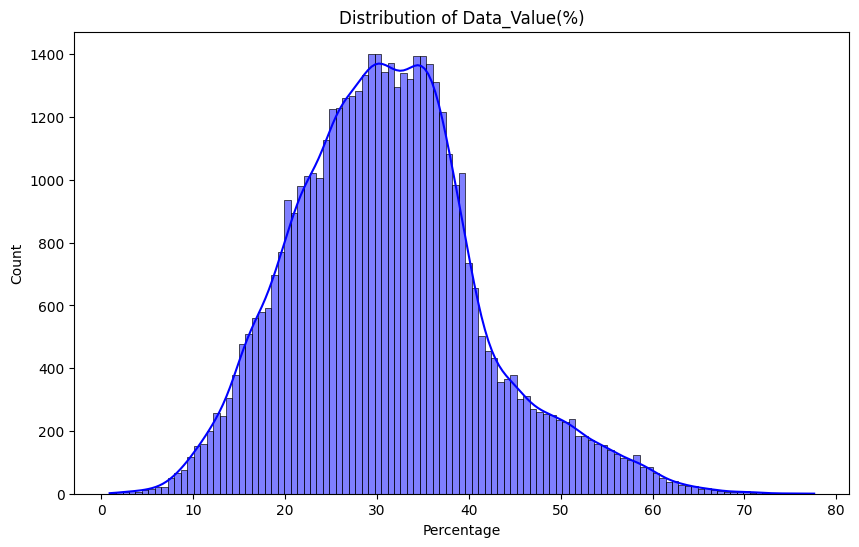

Insight: The distribution is multimodal, reflecting different types of questions (e.g., Obesity rates vs Activity rates).


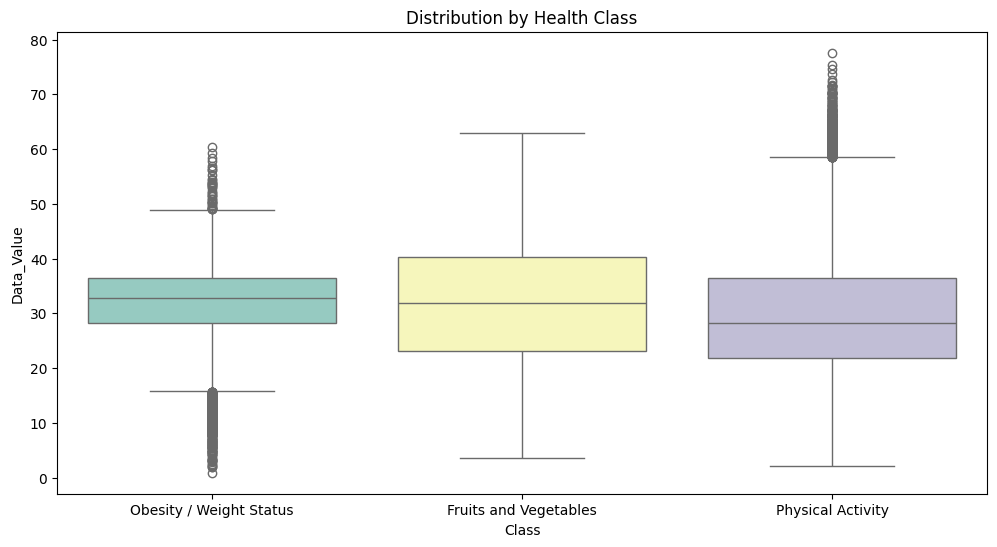

Insight: We can observe the range of percentages for Obesity vs Physical Activity.


In [8]:
# 2. EDA VISUALIZATIONS
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Data_Value'], kde=True, color='blue')
plt.title('Distribution of Data_Value(%)')
plt.xlabel('Percentage')
plt.show()
print("Insight: The distribution is multimodal, reflecting different types of questions (e.g., Obesity rates vs Activity rates).")

plt.figure(figsize=(12, 6))
# Compare Obesity vs Physical Activity values
sns.boxplot(x='Class', y='Data_Value', data=df_clean, palette='Set3')
plt.title('Distribution by Health Class')
plt.show()
print("Insight: We can observe the range of percentages for Obesity vs Physical Activity.")

In [12]:
# ENCODING AND SCALING
# 1. Encode Categorical Variables
# Use LabelEncoder because columns like 'Question' and 'Stratification1' are nominal
le = LabelEncoder()
categorical_cols = ['LocationAbbr', 'Class', 'Topic', 'Question', 'StratificationCategory1', 'Stratification1']

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 2. Split Features (X) and Target (y)
X = df_clean.drop('Data_Value', axis=1)
y = df_clean['Data_Value']

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete.")
print(f"Training Features: {X_train_scaled.shape}")

Data Preprocessing Complete.
Training Features: (38676, 7)


In [13]:
# NEURAL NETWORK REGRESSOR

# Architecture: MLP Regressor
# Layers: Input -> Hidden(100) -> Hidden(50) -> Output(1)
# Activation: ReLU, Optimizer: Adam

mlp_reg = MLPRegressor(hidden_layer_sizes=(100, 50),
                       activation='relu',
                       solver='adam',
                       max_iter=300,
                       random_state=42)

print("Training Neural Network ...")
mlp_reg.fit(X_train_scaled, y_train)

# Evaluation
y_pred_mlp = mlp_reg.predict(X_test_scaled)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("\nNeural Network Results ")
print(f"RMSE: {rmse_mlp:.4f}")
print(f"R-squared: {r2_mlp:.4f}")

Training Neural Network ...

Neural Network Results 
RMSE: 4.9885
R-squared: 0.7596


In [14]:
# PRIMARY MODELS (CLASSICAL)

# Model 1: Random Forest Regressor
# Ensemble method, excellent for mixed categorical/numerical data
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)

# Model 2: Decision Tree Regressor
# Baseline tree model
dt_model = DecisionTreeRegressor(random_state=42)

print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

print("Training Decision Tree...")
dt_model.fit(X_train_scaled, y_train)

# Evaluation
y_pred_rf = rf_model.predict(X_test_scaled)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

y_pred_dt = dt_model.predict(X_test_scaled)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("\nClassical Models Initial Results ")
print(f"Random Forest - R2: {r2_rf:.4f}, RMSE: {rmse_rf:.4f}")
print(f"Decision Tree - R2: {r2_dt:.4f}, RMSE: {rmse_dt:.4f}")

Training Random Forest...
Training Decision Tree...

Classical Models Initial Results 
Random Forest - R2: 0.8415, RMSE: 4.0503
Decision Tree - R2: 0.7419, RMSE: 5.1684


In [15]:
# HYPERPARAMETER OPTIMIZATION
# Using RandomizedSearchCV

# 1. Random Forest Tuning
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Decision Tree Tuning
dt_params = {
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10]
}

print("Tuning Random Forest...")
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, n_iter=5, scoring='r2', random_state=42, n_jobs=-1)
rf_search.fit(X_train_scaled, y_train)

print("Tuning Decision Tree...")
dt_search = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=3, n_iter=5, scoring='r2', random_state=42, n_jobs=-1)
dt_search.fit(X_train_scaled, y_train)

print("\n Optimization Results for RF")
print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best RF CV Score (R2): {rf_search.best_score_:.4f}")

Tuning Random Forest...
Tuning Decision Tree...

 Optimization Results for RF
Best RF Params: {'n_estimators': 50, 'min_samples_leaf': 2, 'max_depth': 20}
Best RF CV Score (R2): 0.8328


In [17]:
print("\nOptimization Results for DT")
print(f"Best DT Params: {dt_search.best_params_}")
print(f"Best DT CV Score (R2): {dt_search.best_score_:.4f}")


Optimization Results for DT
Best DT Params: {'min_samples_split': 10, 'max_depth': None}
Best DT CV Score (R2): 0.7863


In [18]:
# FEATURE SELECTION
# Technique: SelectKBest (Filter Method) using f_regression
# Rationale: Selects the top k features with the strongest statistical relationship to the target.

print("Feature Selection...")

# Select top 4 features (out of the available 7)
selector = SelectKBest(score_func=f_regression, k=4)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

# Identify selected features
mask = selector.get_support()
selected_features = X.columns[mask]

print(f"Original Feature Count: {X.shape[1]}")
print(f"Selected Features: {list(selected_features)}")

Feature Selection...
Original Feature Count: 7
Selected Features: ['Class', 'Topic', 'Question', 'Stratification1']


In [20]:
# MODELS AND COMPARISON

# Rebuild Models with Best Params AND Selected Features

# 1. Final Random Forest
final_rf = rf_search.best_estimator_
final_rf.fit(X_train_sel, y_train)
pred_rf = final_rf.predict(X_test_sel)

# 2. Final Decision Tree
final_dt = dt_search.best_estimator_
final_dt.fit(X_train_sel, y_train)
pred_dt = final_dt.predict(X_test_sel)

# Metrics Helper
def get_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred)
    }

metrics_rf = get_metrics(y_test, pred_rf)
metrics_dt = get_metrics(y_test, pred_dt)

# Comparison Table
comparison_df = pd.DataFrame([metrics_rf, metrics_dt], index=['Random Forest (Optimized)', 'Decision Tree (Optimized)'])
comparison_df['CV Score (Best)'] = [rf_search.best_score_, dt_search.best_score_]

print("\nTable 2: Comparison of Final Regression Models")
display(comparison_df)

best_model = (
    comparison_df[['R2 Score', 'CV Score (Best)']]
    .mean(axis=1)
    .idxmax()
)
print(f"{best_model}")
print(f"\nConclusion: The {best_model} is the best performing model.")


Table 2: Comparison of Final Regression Models


,MAE,RMSE,R2 Score,CV Score (Best)
Random Forest (Optimized),3.562203,4.792473,0.778085,0.832812
Decision Tree (Optimized),3.560837,4.791191,0.778204,0.786274


Random Forest (Optimized)

Conclusion: The Random Forest (Optimized) is the best performing model.
